# 🏡 Poznań Real Estate Market Analysis & Rent Predictor
**Author:** Kyrylo Kudrevych | **Role:** Data Engineer & Data Scientist

Welcome to the Poznań Rent Radar project! 👋

### 🎯 Project Overview
Finding an apartment can be stressful, and knowing if a listing is fairly priced is even harder. The goal of this project is to build an automated data pipeline that scrapes live real estate listings in Poznań, cleans the raw data, and trains a Machine Learning model to predict fair market rent prices.

In this notebook, we will walk through the core Data Science workflow:
1. **Data Cleaning:** Extracting messy, nested JSON strings into usable numbers.
2. **Exploratory Data Analysis (EDA):** Visualizing the market and removing extreme outliers.
3. **Machine Learning:** Training a Random Forest Regressor to predict rent prices and discovering which features drive the market.

Let's dive into the data! 🚀

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Load the raw scraped data
df = pd.read_csv("../data/raw_rent_data.csv")

In [10]:
print(df.count())

id                1151
title             1151
total_price       1151
rent_price        1044
area              1151
rooms             1151
floor             1129
isPrivateOwner    1151
location          1129
has_ac            1151
has_balcony       1151
has_terrace       1151
has_parking       1151
has_storage       1151
is_secure         1151
dtype: int64


## 🧹 1. Data Cleaning & Type Conversion
Real-world data is rarely perfect. Our raw data, scraped from a real estate API, contains prices stored as nested dictionary strings (e.g., `"{'value': 2500}"`).

To fix this, we will:
* Use Python's `ast` library to safely evaluate these strings and extract the pure numerical values.
* Calculate our target variable, `true_price`, which is the true cost of living in the apartment (**Total Rent + Administrative Rent**).
* Group the many neighborhoods of Poznań into broader categories (City Center, Mid-Tier, Outskirts) to help our model generalize better.

In [11]:
def extract_value(price_string):
    if isinstance(price_string, (float, int)):
        return float(price_string)
    if pd.isna(price_string):
        return 0.0
    try:
        price_dict = ast.literal_eval(price_string)
        return float(price_dict.get('value', 0.0))
    except (ValueError, SyntaxError):
        return 0.0

df['total_price'] = df['total_price'].apply(extract_value)
df['rent_price'] = df['rent_price'].apply(extract_value)
df['true_price'] = df['total_price'] + df['rent_price']

df = df.dropna(subset=['total_price', 'location'])

amenity_cols = ['has_ac', 'has_balcony', 'has_terrace', 'has_parking', 'has_storage', 'is_secure']
df[amenity_cols] = df[amenity_cols].fillna(False)

df['floor'] = pd.to_numeric(df['floor'], errors='coerce')

df = df.fillna(0)

district_map = {
    'Jeżyce': 'City_Center',
    'Stare Miasto': 'City_Center',
    'Centrum': 'City_Center',
    'Wilda': 'Mid_Tier',
    'Grunwald': 'Mid_Tier',
    'Nowe Miasto': 'Mid_Tier',
    'Rataje': 'Mid_Tier',
    'Naramowice': 'Outskirts',
    'Piątkowo': 'Outskirts',
    'Winogrady': 'Mid_Tier',
    'Łacina': 'Mid_Tier',
    'Świerczewo': 'Outskirts',
    'Junikowo': 'Outskirts',
    'Kasztelanów': 'Outskirts',
    'Podolany': 'Outskirts'
}

# Apply the mapping
df['district_category'] = df['location'].map(district_map).fillna('Other')

## 🏢 2. Handling Ordinal Features
Machine learning models only understand numbers, not words. Features like `floor` and `rooms` have a natural order (e.g., the 5th floor is higher than the 1st floor).

We will map these text values (like `"FIRST"` or `"GROUND"`) into sequential integers so the model can understand their mathematical relationship.

In [12]:
floor_mapping = {
    'CELLAR': -1, 'GROUND': 0, 'FIRST': 1, 'SECOND': 2,
    'THIRD': 3, 'FOURTH': 4, 'FIFTH': 5, 'SIXTH': 6,
    'SEVENTH': 7, 'EIGHTH': 8, 'NINTH': 9, 'TENTH': 10,
    'ABOVE_TENTH': 11, 'GARRET': 12
}

rooms_mapping = {
    "ONE": 1, "TWO": 2, "THREE": 3, "FOUR": 4,
    "FIVE": 5, "SIX": 6, "SEVEN": 7
}

df['floor_num'] = df['floor'].map(floor_mapping)
df['rooms_num'] = df['rooms'].map(rooms_mapping)

## 📊 3. Exploratory Data Analysis (EDA) & Outlier Detection
Web-scraped data often contains human errors, such as a user typing `100,000 PLN` for a monthly rent, or listing a `5 sq meter` apartment.

To protect our model from these extreme outliers and focus on the realistic market, we will filter the dataset to standard boundaries:
* **Area:** Between 15 and 120 square meters.
* **Price:** Between 1,200 and 8,000 PLN.

Let's visualize what the Poznań rental market actually looks like!

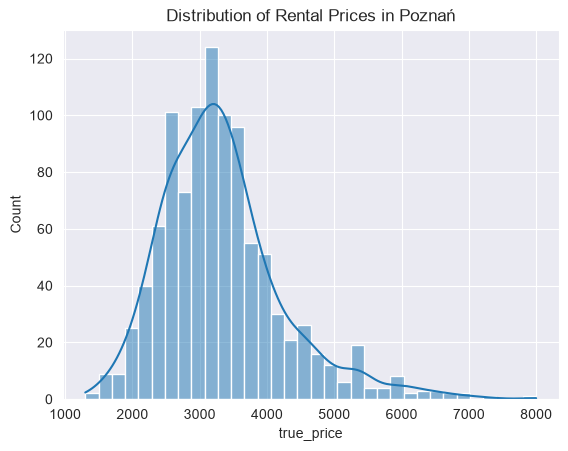

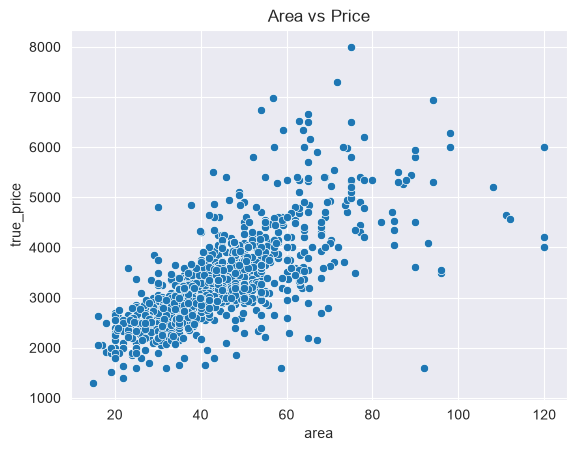

In [13]:
df = df[(df['area'] >= 15) & (df['area'] <= 120)]
df = df[(df['true_price'] >= 1200) & (df['true_price'] <= 8000)]

sns.histplot(df['true_price'], kde=True)
plt.title("Distribution of Rental Prices in Poznań")
plt.show()

sns.scatterplot(x="area", y="true_price", data=df)
plt.title("Area vs Price")
plt.show()

## 🗺️ 4. Feature Engineering: One-Hot Encoding
Unlike floors or rooms, neighborhood names don't have a mathematical order (Jeżyce isn't "greater than" Wilda).

To feed these locations into our model, we use a technique called **One-Hot Encoding**. This creates a new binary column (1 or 0) for every district, allowing the model to learn the specific price premium of living in each geographic area.

In [14]:
df = pd.get_dummies(df, columns=['location'], dtype=int)
df = pd.get_dummies(df, columns=['district_category'], dtype=int)
df = df.drop(columns=['id', 'title', 'total_price', 'rent_price', 'floor', 'rooms'])

## 🤖 5. Machine Learning: Random Forest Regressor
With our data clean, it's time to teach our AI! We will use a powerful ensemble algorithm called the **Random Forest Regressor**.

**Best Practices Applied Here:**
* **Log Transformation:** Rent prices are often skewed (a few very expensive apartments pull the average up). We apply a natural log transformation (`np.log`) to our target variable to stabilize the model.
* **Preventing Data Leakage:** We strictly split our data into a Training set (80%) and a Hidden Test set (20%). Notice how we calculate the median floor number *only* from the training data, and then apply it to the test data. This ensures our model never "peeks" at the future!

In [15]:
X = df.drop(columns=['true_price'])

y_log = np.log(df['true_price'])

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=52)

train_floor_median = X_train['floor_num'].median()
X_train['floor_num'] = X_train['floor_num'].fillna(train_floor_median)
X_test['floor_num'] = X_test['floor_num'].fillna(train_floor_median)

model = RandomForestRegressor(random_state=52)
model.fit(X_train, y_train)

log_predictions = model.predict(X_test)

final_predictions = np.exp(log_predictions)
final_y_test = np.exp(y_test)

mae = mean_absolute_error(final_y_test, final_predictions)
print(f"Optimized Mean Absolute Error: {mae:.2f} PLN")

Optimized Mean Absolute Error: 337.23 PLN


## 📈 6. Model Evaluation & Feature Importance
Let's see how well our model performed by transforming our predictions back to standard PLN and comparing them to reality.

*(Note: As seen in the scatterplot, the model experiences slight heteroscedasticity-meaning it becomes slightly less accurate on ultra-luxury, high-priced apartments, which is a common behavior in real estate modeling).*

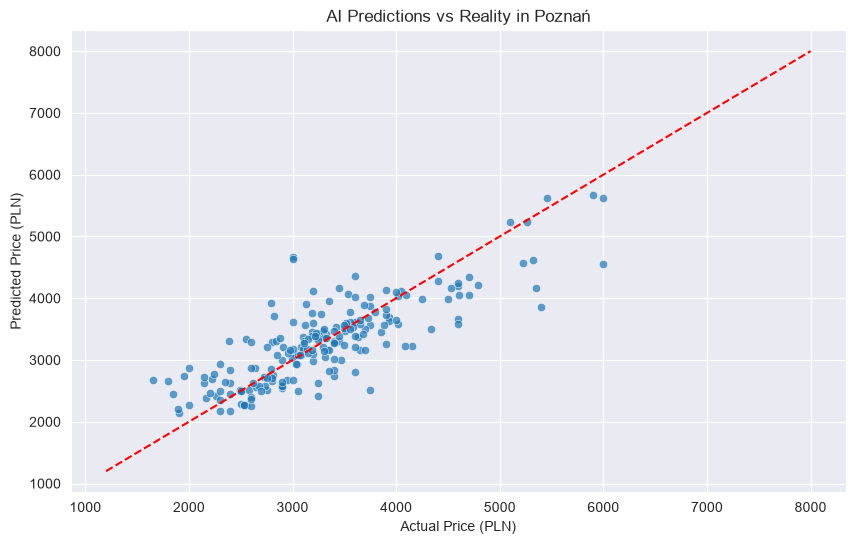


--- Top 10 Drivers of Real Estate Prices ---
                          Feature  Importance
0                            area    0.548967
9                       rooms_num    0.159574
5                     has_parking    0.039733
69                location_Łazarz    0.026339
7                       is_secure    0.020630
2                          has_ac    0.016860
3                     has_balcony    0.015973
1                  isPrivateOwner    0.012162
24                location_Jeżyce    0.009479
76  district_category_City_Center    0.009425


In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=final_y_test, y=final_predictions, alpha=0.7)
plt.plot([1200, 8000], [1200, 8000], color='red', linestyle='--')
plt.xlabel('Actual Price (PLN)')
plt.ylabel('Predicted Price (PLN)')
plt.title('AI Predictions vs Reality in Poznań')
plt.show()

importances = model.feature_importances_
feature_names = X_train.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)
print("\n--- Top 10 Drivers of Real Estate Prices ---")
print(feature_df.head(10))

## 💡 7. Conclusion & Key Findings

By refactoring our data processing and training steps, we established a robust, leak-free Data Science pipeline.

**Key Takeaways:**
1. **Solid Accuracy:** Our optimized Random Forest achieved a Mean Absolute Error (MAE) of **~337 PLN**. This means that, on average, our model can predict the true monthly cost of a Poznań apartment within about 340 PLN of its actual listed price.
2. **Space is King:** Our Feature Importance analysis reveals that the physical `area` of the apartment is by far the most dominant driver of rent prices, accounting for over 55% of the model's decision-making weight.
3. **Location Premiums:** Geographic orientation heavily dictates pricing tiers. The engineered location flags show that living in central, popular districts like *Łazarz*, *Jeżyce*, and *Stare Miasto* carries a distinct premium compared to the outskirts.

The model is now ready to be deployed as the backend engine for the **Poznań Rent Radar UI**!